# 10 — Monitoramento do Modelo: Drift e Performance

**Objetivo:** Avaliar a saúde do modelo ao longo do tempo — detectar drift de features e de score,
e confirmar a performance medida em validação (onde os rótulos reais estão disponíveis).

## O que este notebook verifica

| Seção | Pergunta respondida |
|---|---|
| Score Distribution | A distribuição de probabilidades mudou entre treino → validação → aplicação? |
| Feature Drift (PSI) | As features mais importantes mudaram significativamente na aplicação? |
| Performance em Validação | O modelo atinge a precisão estimada quando comparado com rótulos reais? |
| Classificação ao longo do tempo | A proporção de Alto/Médio/Baixo é estável mês a mês? |
| Critérios de Retreino | Quando os sinais indicam que o modelo deve ser retreinado? |

## Dados utilizados

| Conjunto | Período | Labels? |
|---|---|---|
| `base_features_tt` (últimos 3m) | Mar–Mai/2025 | ✅ Sim |
| `base_features_val` | Jun–Ago/2025 | ✅ Sim |
| `base_features_apl` | Set–Dez/2025 | ❌ Não (horizonte futuro) |

---

| Entrada | Arquivo |
|---|---|
| Features treino/val/apl | `data/gold/base_features_{tt,val,apl}.parquet` |
| Modelos tunados | `models/{Grupo}/best_model_tuned.joblib` |
| Scalers | `models/{Grupo}/standard_scaler.joblib` |
| SHAP feature importance | `reports/shap/{Grupo}/shap_feature_importance.json` |
| Score consolidado | `reports/score_risco_consolidado.parquet` |

| Saída | Arquivo |
|---|---|
| Relatório de drift PSI | `reports/monitor_drift_psi.csv` |
| Relatório de performance val | `reports/monitor_performance_val.csv` |
| Figura — Distribuição de score | `reports/figures/monitor_score_dist.png` |
| Figura — Drift PSI por feature | `reports/figures/monitor_psi_heatmap.png` |
| Figura — Performance em validação | `reports/figures/monitor_performance_val.png` |
| Figura — Classificação ao longo do tempo | `reports/figures/monitor_classificacao_tempo.png` |

## 1 · Setup & Configuração

In [1]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
import joblib
from pathlib import Path
from datetime import datetime
from scipy import stats
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix)

matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")

pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-05-05 15:42


In [2]:

# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd().parent
DATA_GOLD    = PROJECT_ROOT / "data" / "gold"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection"
FIGURES_DIR  = REPORTS_DIR / "figures"
SHAP_DIR     = REPORTS_DIR / "shap"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COL_ID     = "id_colaborador"
COL_GRUPO  = "ds_grupo"
COL_DATA   = "dt_mes_ano"
COL_TARGET = "fg_demitido_voluntario_4m"
GRUPOS     = ["Vendas", "Transporte", "Fábrica"]
META_COLS  = [COL_ID, COL_GRUPO, COL_DATA, COL_TARGET, "fg_sem_output"]

# Número de features top-SHAP a analisar no drift
TOP_N_SHAP = 10

# Thresholds PSI
PSI_WARN   = 0.10   # amarelo: mudança moderada
PSI_ALERT  = 0.20   # vermelho: mudança significativa — investigar/retreinar

# Limiar de AUC mínima aceitável (abaixo → sinal de retreino)
AUC_MIN    = 0.65

# Reference rates por grupo (calculadas em 08_score — últimos 3m de base_features_tt)
REF_RATES  = {"Vendas": 0.1235, "Transporte": 0.1027, "Fábrica": 0.1258}

# Precision A+M de validação (referência do 08_score)
PRECISION_AM_REF = {"Vendas": 0.281, "Transporte": 0.265, "Fábrica": 0.325}

print(f"FS_DIR     : {FS_DIR}")
print(f"MODELS_DIR : {MODELS_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")
print(f"\nParâmetros:")
print(f"  TOP_N_SHAP : {TOP_N_SHAP}")
print(f"  PSI_WARN   : {PSI_WARN}  |  PSI_ALERT: {PSI_ALERT}")
print(f"  AUC_MIN    : {AUC_MIN}")


FS_DIR     : G:\Meu Drive\Rafael\Desemprego\projetos github\clonados\projeto1_modelo_preditivo\data\processed\feature_selection
MODELS_DIR : G:\Meu Drive\Rafael\Desemprego\projetos github\clonados\projeto1_modelo_preditivo\models
REPORTS_DIR: G:\Meu Drive\Rafael\Desemprego\projetos github\clonados\projeto1_modelo_preditivo\reports

Parâmetros:
  TOP_N_SHAP : 10
  PSI_WARN   : 0.1  |  PSI_ALERT: 0.2
  AUC_MIN    : 0.65


## 2 · Carregar dados e modelos

In [3]:

# ── Carregar bases de features ────────────────────────────────
bftt  = pd.read_parquet(DATA_GOLD / "base_features_tt.parquet")
bfval = pd.read_parquet(DATA_GOLD / "base_features_val.parquet")
bfapl = pd.read_parquet(DATA_GOLD / "base_features_apl.parquet")

# Últimos 3 meses do treino (referência estável)
meses_tt_sorted = sorted(bftt[COL_DATA].unique())
ref_tt = bftt[bftt[COL_DATA].isin(meses_tt_sorted[-3:])].copy()

print(f"base_features_tt  : {bftt.shape[0]:,} linhas  | {bftt[COL_DATA].nunique()} meses")
print(f"  → últimos 3m ref: {ref_tt.shape[0]:,} linhas  | "
      f"{sorted(ref_tt[COL_DATA].dt.strftime('%Y-%m').unique())}")
print(f"base_features_val : {bfval.shape[0]:,} linhas  | "
      f"{sorted(bfval[COL_DATA].dt.strftime('%Y-%m').unique())}")
print(f"base_features_apl : {bfapl.shape[0]:,} linhas  | "
      f"{sorted(bfapl[COL_DATA].dt.strftime('%Y-%m').unique())}")

# ── Carregar modelos, scalers, features selecionadas e SHAP ───
modelos = {}; scalers = {}; scaler_cols = {}; shap_top = {}; selected_feats = {}

for grupo in GRUPOS:
    modelos[grupo]  = joblib.load(MODELS_DIR / grupo / "best_model_tuned.joblib")
    scalers[grupo]  = joblib.load(MODELS_DIR / grupo / "standard_scaler.joblib")

    sc_path = DATA_GOLD.parent / "processed" / "splits" / grupo / "scaler_cols.json"
    if not sc_path.exists():
        sc_path = DATA_GOLD.parent / "processed" / "splits" / "scaler_cols.json"
    with open(sc_path, encoding="utf-8") as f:
        sc_cfg = json.load(f)
    scaler_cols[grupo] = sc_cfg["scale_cols"]

    with open(FS_DIR / grupo / "selected_features.json", encoding="utf-8") as f:
        selected_feats[grupo] = json.load(f)["selected_features"]

    with open(SHAP_DIR / grupo / "shap_feature_importance.json") as f:
        shap_raw = json.load(f)
    shap_top[grupo] = [e["feature"] for e in shap_raw[:TOP_N_SHAP]]
    print(f"  {grupo}: modelo={type(modelos[grupo]).__name__}  "
          f"n_selected={len(selected_feats[grupo])}  "
          f"top3={shap_top[grupo][:3]}")

# ── Score consolidado (aplicação) ────────────────────────────
score_apl = pd.read_parquet(REPORTS_DIR / "score_risco_consolidado.parquet")
print(f"\nScore aplicação: {score_apl.shape}")


base_features_tt  : 106,902 linhas  | 17 meses


  → últimos 3m ref: 17,953 linhas  | ['2025-03', '2025-04', '2025-05']


base_features_val : 17,430 linhas  | ['2025-06', '2025-07', '2025-08']


base_features_apl : 25,164 linhas  | ['2025-09', '2025-10', '2025-11', '2025-12']


  Vendas: modelo=XGBClassifier  n_selected=70  top3=['vl_dias_menos_6_horas_max_6m_bin', 'vl_remuneracao_variavel_max_3m', 'vl_idade']
  Transporte: modelo=XGBClassifier  n_selected=69  top3=['vl_idade', 'vl_dias_menos_6_horas', 'vl_filhos']
  Fábrica: modelo=XGBClassifier  n_selected=69  top3=['vl_dias_noturno_std_6m', 'vl_saldo_banco_horas_med_3m_std_3m', 'vl_idade']

Score aplicação: (25164, 8)


## 3 · Score na validação (computa predições onde temos rótulos reais)

In [4]:

# ────────────────────────────────────────────────────────────────
# Aplica modelo tunado na base_features_val para obter probabilidades.
# Mesma lógica do 08_score: escalar scale_cols primeiro, depois
# subsetar para selected_features do modelo.
# ────────────────────────────────────────────────────────────────

registros_val = []

for grupo in GRUPOS:
    df_g    = bfval[bfval[COL_GRUPO] == grupo].copy()
    sc_cols = scaler_cols[grupo]
    model   = modelos[grupo]
    scaler  = scalers[grupo]

    # 1. Aplicar scaler nas colunas escaláveis presentes
    sc_present = [c for c in sc_cols if c in df_g.columns]
    if sc_present:
        df_g[sc_present] = scaler.transform(df_g[sc_present])

    # 2. Subsetar para as features selecionadas pelo modelo
    s_feats = [c for c in selected_feats[grupo] if c in df_g.columns]
    X = df_g[s_feats].copy()
    proba = model.predict_proba(X)[:, 1]

    # Ranking por mês → método 2
    ref_rate  = REF_RATES[grupo]
    alto_pct  = ref_rate * 1.4
    medio_pct = alto_pct * 0.5

    df_g = df_g.reset_index(drop=True)
    df_g["proba_turnover"] = proba

    labels = []
    for mes in sorted(df_g[COL_DATA].unique()):
        mask  = df_g[COL_DATA] == mes
        df_m  = df_g[mask].copy()
        n     = len(df_m)
        ranks = df_m["proba_turnover"].rank(ascending=False, method="first")
        cut_a = int(np.ceil(n * alto_pct))
        cut_m = int(np.ceil(n * (alto_pct + medio_pct)))
        lbl   = pd.Series("Baixo", index=df_m.index)
        lbl[ranks <= cut_a] = "Alto"
        lbl[(ranks > cut_a) & (ranks <= cut_m)] = "Médio"
        labels.append(lbl)

    df_g["grupo_risco"] = pd.concat(labels).reindex(df_g.index)

    rec = df_g[[COL_ID, COL_GRUPO, COL_DATA, COL_TARGET,
                "proba_turnover", "grupo_risco"]].copy()
    rec["alto_pct"]  = alto_pct
    rec["medio_pct"] = medio_pct
    registros_val.append(rec)

    print(f"  {grupo}: Alto={( df_g['grupo_risco']=='Alto').mean()*100:.1f}%  "
          f"Médio={( df_g['grupo_risco']=='Médio').mean()*100:.1f}%")

df_val_score = pd.concat(registros_val, ignore_index=True)
df_val_score["pred_am"] = df_val_score["grupo_risco"].isin(["Alto", "Médio"]).astype(int)
df_val_score["pred_a"]  = (df_val_score["grupo_risco"] == "Alto").astype(int)
print(f"\nScore validação total: {df_val_score.shape}")


  Vendas: Alto=17.3%  Médio=8.6%


  Transporte: Alto=14.4%  Médio=7.2%


  Fábrica: Alto=17.7%  Médio=8.8%

Score validação total: (17430, 10)


## 4 · Performance em validação (labels reais)

In [5]:
# ────────────────────────────────────────────────────────────────
# Métricas por grupo — usa rótulos reais do período Jun–Ago/2025
# ────────────────────────────────────────────────────────────────

# Mapeamento: Alto=1, Médio=1 ("em risco"), Baixo=0
df_val_score["pred_am"] = (df_val_score["grupo_risco"].isin(["Alto", "Médio"])).astype(int)
df_val_score["pred_a"]  = (df_val_score["grupo_risco"] == "Alto").astype(int)
y_true_all = df_val_score[COL_TARGET].fillna(0).astype(int)

rows = []

for grupo in GRUPOS:
    dg    = df_val_score[df_val_score[COL_GRUPO] == grupo]
    y     = dg[COL_TARGET].fillna(0).astype(int)
    proba = dg["proba_turnover"]
    pred_am = dg["pred_am"]
    pred_a  = dg["pred_a"]

    try:
        auc_roc = roc_auc_score(y, proba)
        pr_auc  = average_precision_score(y, proba)
    except Exception:
        auc_roc = np.nan
        pr_auc  = np.nan

    prec_am = precision_score(y, pred_am, zero_division=0)
    rec_am  = recall_score(y, pred_am, zero_division=0)
    f1_am   = f1_score(y, pred_am, zero_division=0)
    prec_a  = precision_score(y, pred_a, zero_division=0)
    rec_a   = recall_score(y, pred_a, zero_division=0)

    n_pos   = y.sum()
    n_total = len(y)
    target_rate = y.mean()

    rows.append({
        "grupo"      : grupo,
        "n_total"    : n_total,
        "n_positivos": int(n_pos),
        "taxa_target": round(target_rate, 3),
        "auc_roc"    : round(auc_roc, 3),
        "pr_auc"     : round(pr_auc, 3),
        "prec_AM"    : round(prec_am, 3),
        "rec_AM"     : round(rec_am, 3),
        "f1_AM"      : round(f1_am, 3),
        "prec_AM_ref": PRECISION_AM_REF[grupo],
        "prec_A"     : round(prec_a, 3),
        "rec_A"      : round(rec_a, 3),
        "alerta_auc" : "⚠️" if auc_roc < AUC_MIN else "✅",
    })

df_perf = pd.DataFrame(rows)

print("="*72)
print("PERFORMANCE EM VALIDAÇÃO (Jun–Ago/2025) — rótulos reais")
print("="*72)
print()
for _, r in df_perf.iterrows():
    print(f"  {r['grupo']}  {r['alerta_auc']}")
    print(f"    n={r['n_total']:,}  positivos={r['n_positivos']:,}  "
          f"taxa_target={r['taxa_target']*100:.1f}%")
    print(f"    AUC-ROC={r['auc_roc']:.3f}  PR-AUC={r['pr_auc']:.3f}")
    print(f"    Alto+Médio — Precision={r['prec_AM']:.3f}  "
          f"(ref. usada no ROI: {r['prec_AM_ref']:.3f})  "
          f"Recall={r['rec_AM']:.3f}  F1={r['f1_AM']:.3f}")
    print(f"    Alto       — Precision={r['prec_A']:.3f}  "
          f"Recall={r['rec_A']:.3f}")
    print()

df_perf.to_csv(REPORTS_DIR / "monitor_performance_val.csv", index=False)
print(f"✓ monitor_performance_val.csv salvo")

PERFORMANCE EM VALIDAÇÃO (Jun–Ago/2025) — rótulos reais

  Vendas  ✅
    n=6,641  positivos=774  taxa_target=11.7%
    AUC-ROC=0.744  PR-AUC=0.284
    Alto+Médio — Precision=0.252  (ref. usada no ROI: 0.281)  Recall=0.561  F1=0.347
    Alto       — Precision=0.299  Recall=0.444

  Transporte  ✅
    n=8,631  positivos=849  taxa_target=9.8%
    AUC-ROC=0.718  PR-AUC=0.225
    Alto+Médio — Precision=0.212  (ref. usada no ROI: 0.265)  Recall=0.465  F1=0.291
    Alto       — Precision=0.257  Recall=0.376

  Fábrica  ✅
    n=2,158  positivos=203  taxa_target=9.4%
    AUC-ROC=0.734  PR-AUC=0.290
    Alto+Médio — Precision=0.184  (ref. usada no ROI: 0.325)  Recall=0.517  F1=0.271
    Alto       — Precision=0.215  Recall=0.404

✓ monitor_performance_val.csv salvo


## 5 · Drift de features — PSI (Population Stability Index)

In [6]:

# ────────────────────────────────────────────────────────────────
# PSI: compara distribuição de cada feature entre treino (ref) e
# aplicação (alvo). Bins definidos com base na distribuição do treino.
#
# PSI = Σ (P_obs - P_ref) * ln(P_obs / P_ref)
# < 0.10 → estável | 0.10–0.20 → alerta moderado | ≥ 0.20 → alerta crítico
# ────────────────────────────────────────────────────────────────

def calcular_psi(ref: np.ndarray, obs: np.ndarray, n_bins: int = 10) -> float:
    breaks = np.nanpercentile(ref, np.linspace(0, 100, n_bins + 1))
    breaks = np.unique(breaks)
    if len(breaks) < 2:
        return 0.0
    ref_c = np.clip(ref, breaks[0], breaks[-1])
    obs_c = np.clip(obs, breaks[0], breaks[-1])
    p_ref, _ = np.histogram(ref_c, bins=breaks)
    p_obs, _ = np.histogram(obs_c, bins=breaks)
    p_ref = p_ref / p_ref.sum()
    p_obs = p_obs / p_obs.sum()
    p_ref = np.where(p_ref == 0, 1e-4, p_ref)
    p_obs = np.where(p_obs == 0, 1e-4, p_obs)
    return float(np.sum((p_obs - p_ref) * np.log(p_obs / p_ref)))


rows_psi = []

for grupo in GRUPOS:
    ref_g = ref_tt[ref_tt[COL_GRUPO] == grupo]
    apl_g = bfapl[bfapl[COL_GRUPO] == grupo]
    val_g = bfval[bfval[COL_GRUPO] == grupo]

    for feat in shap_top[grupo]:
        if feat not in ref_g.columns or feat not in apl_g.columns:
            continue
        ref_arr = ref_g[feat].dropna().values.astype(float)
        apl_arr = apl_g[feat].dropna().values.astype(float)
        val_arr = val_g[feat].dropna().values.astype(float)

        psi_val = calcular_psi(ref_arr, val_arr)
        psi_apl = calcular_psi(ref_arr, apl_arr)

        rows_psi.append({
            "grupo"     : grupo,
            "feature"   : feat,
            "psi_val"   : round(psi_val, 4),
            "psi_apl"   : round(psi_apl, 4),
            "status_val": "⚠️ alerta" if psi_val >= PSI_ALERT
                          else ("⚡ moderado" if psi_val >= PSI_WARN else "✅ estável"),
            "status_apl": "⚠️ alerta" if psi_apl >= PSI_ALERT
                          else ("⚡ moderado" if psi_apl >= PSI_WARN else "✅ estável"),
        })

df_psi = pd.DataFrame(rows_psi)

print("PSI — Top features por grupo (ref=últimos 3m treino)")
print()
for grupo in GRUPOS:
    sub = df_psi[df_psi["grupo"] == grupo][["feature", "psi_val", "status_val",
                                              "psi_apl", "status_apl"]]
    print(f"  {grupo}:")
    print(sub.to_string(index=False))
    print()

df_psi.to_csv(REPORTS_DIR / "monitor_drift_psi.csv", index=False)
print(f"✓ monitor_drift_psi.csv salvo")


PSI — Top features por grupo (ref=últimos 3m treino)

  Vendas:
                              feature  psi_val status_val  psi_apl status_apl
     vl_dias_menos_6_horas_max_6m_bin   0.0088  ✅ estável   0.0387  ✅ estável
       vl_remuneracao_variavel_max_3m   0.0034  ✅ estável   0.0034  ✅ estável
                             vl_idade   0.0007  ✅ estável   0.0017  ✅ estável
                            vl_filhos   0.0000  ✅ estável   0.0001  ✅ estável
                vl_dias_menos_6_horas   0.0812  ✅ estável   0.0608  ✅ estável
                     vl_tempo_empresa   0.0307  ✅ estável   0.0416  ✅ estável
   vl_remuneracao_variavel_std_3m_bin   0.0009  ✅ estável   0.0019  ✅ estável
vl_horas_extras_extraordinarias_horas   1.0757  ⚠️ alerta   1.0611  ⚠️ alerta
     vl_distancia_trabalho_min_max_6m   0.0024  ✅ estável   0.0036  ✅ estável
          vl_horas_trabalhadas_std_3m   0.1659 ⚡ moderado   0.7413  ⚠️ alerta

  Transporte:
                     feature  psi_val status_val  psi_apl statu

## 6 · Visualizações

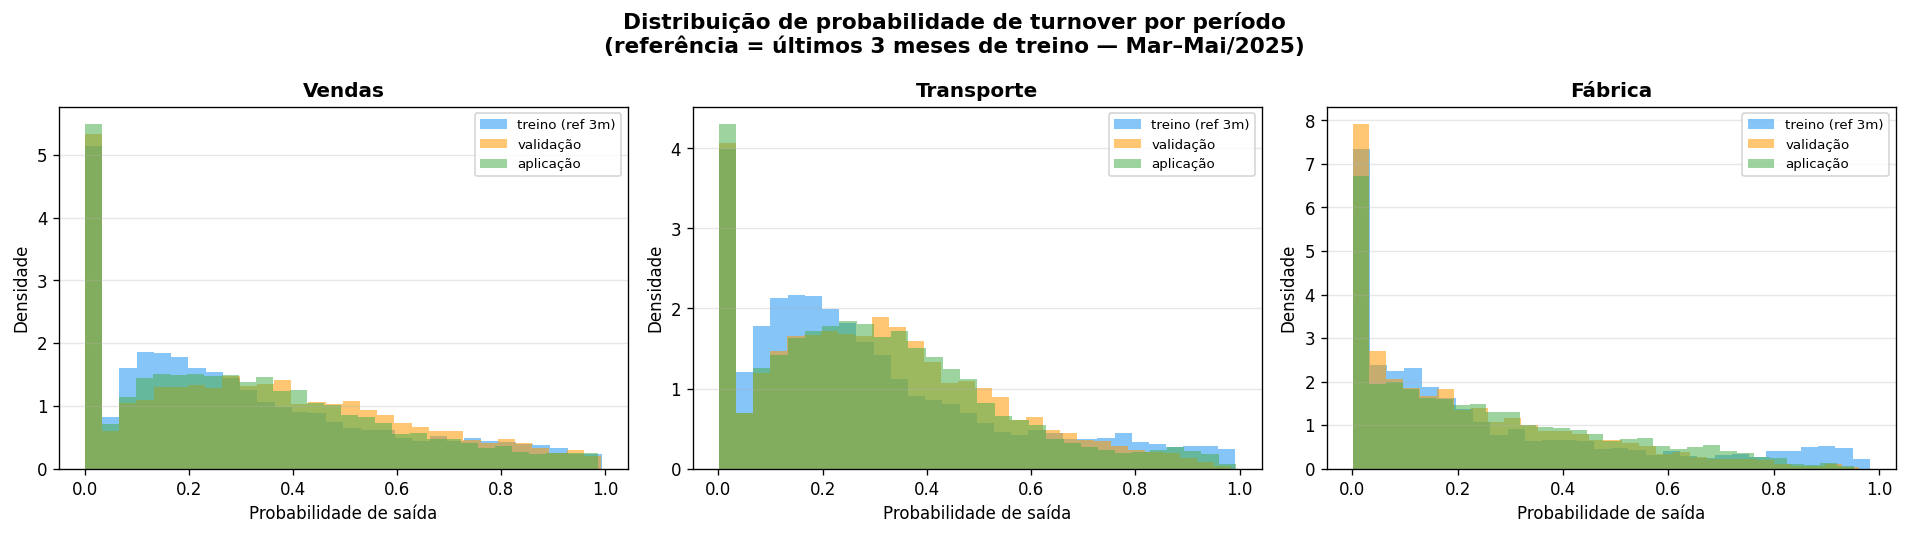

✓ monitor_score_dist.png salvo


In [7]:

# ── Figura 1: Distribuição de probabilidade por período ───────
CORES = {"treino (ref 3m)": "#2196F3", "validação": "#FF9800", "aplicação": "#4CAF50"}

# Calcular probas para ref_tt (últimos 3m treino)
proba_ref_by_grupo = {}
for grupo in GRUPOS:
    ref_g = ref_tt[ref_tt[COL_GRUPO] == grupo].copy()
    sc_p = [c for c in scaler_cols[grupo] if c in ref_g.columns]
    if sc_p:
        ref_g[sc_p] = scalers[grupo].transform(ref_g[sc_p])
    s_feats = [c for c in selected_feats[grupo] if c in ref_g.columns]
    X = ref_g[s_feats].copy()
    proba_ref_by_grupo[grupo] = modelos[grupo].predict_proba(X)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Distribuição de probabilidade de turnover por período\n"
             "(referência = últimos 3 meses de treino — Mar–Mai/2025)",
             fontsize=13, fontweight="bold")

for ax, grupo in zip(axes, GRUPOS):
    proba_ref = proba_ref_by_grupo[grupo]
    proba_val = df_val_score.loc[df_val_score[COL_GRUPO] == grupo, "proba_turnover"]
    proba_apl = score_apl.loc[score_apl[COL_GRUPO] == grupo, "proba_turnover"]

    ax.hist(proba_ref, bins=30, density=True, alpha=0.55,
            color=CORES["treino (ref 3m)"], label="treino (ref 3m)")
    ax.hist(proba_val, bins=30, density=True, alpha=0.55,
            color=CORES["validação"], label="validação")
    ax.hist(proba_apl, bins=30, density=True, alpha=0.55,
            color=CORES["aplicação"], label="aplicação")

    ax.set_title(grupo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Probabilidade de saída")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitor_score_dist.png", bbox_inches="tight")
plt.show()
print(f"✓ monitor_score_dist.png salvo")


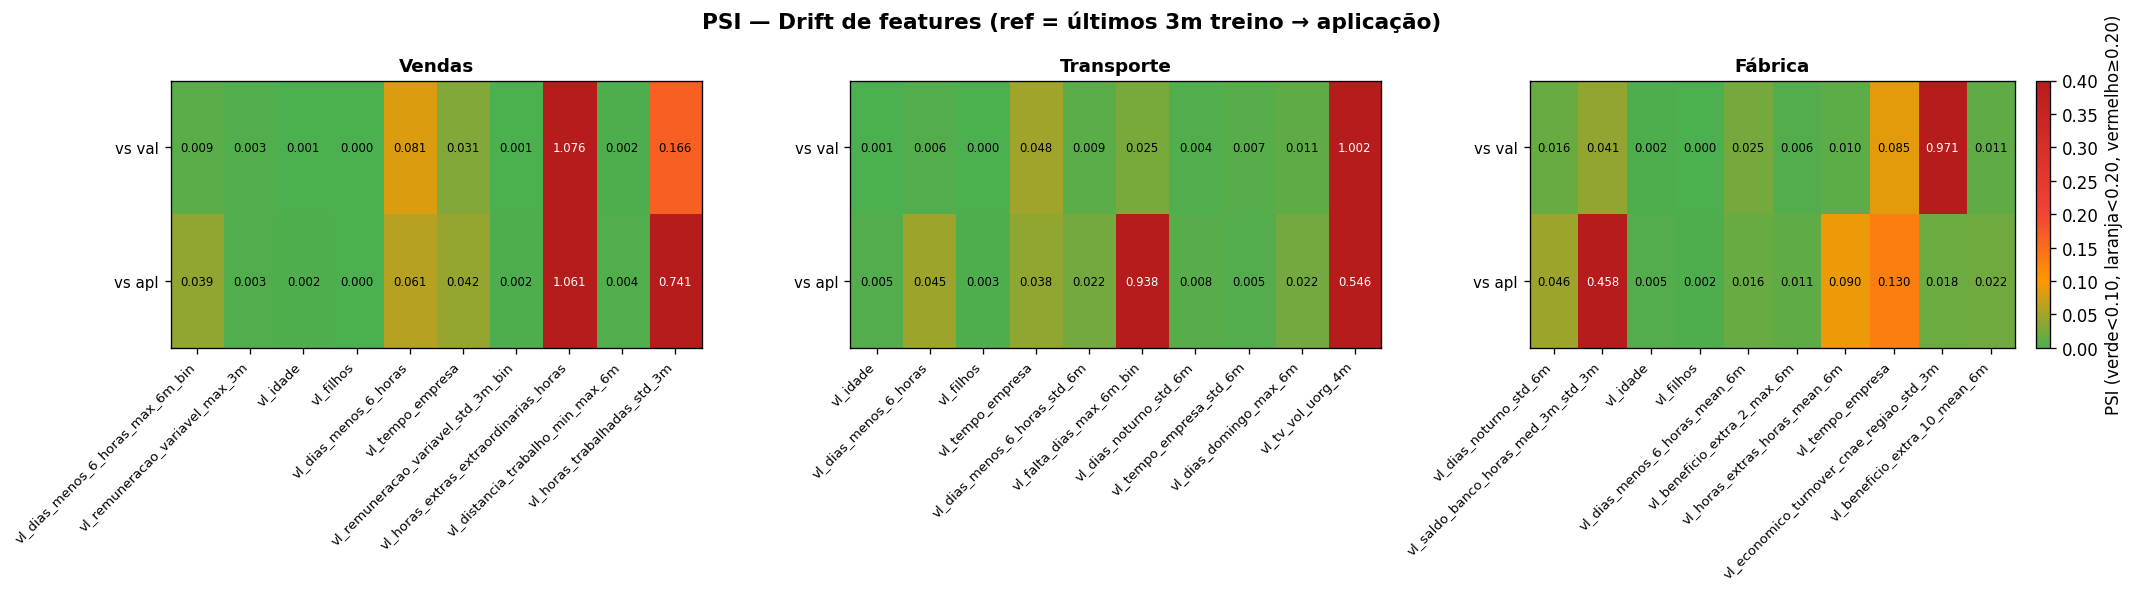

✓ monitor_psi_heatmap.png salvo


In [8]:
# ── Figura 2: Heatmap de PSI por grupo × feature ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PSI — Drift de features (ref = últimos 3m treino → aplicação)",
             fontsize=13, fontweight="bold")

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "psi", [(0, "#4CAF50"), (PSI_WARN / 0.4, "#FF9800"),
            (PSI_ALERT / 0.4, "#F44336"), (1, "#B71C1C")])

for ax, grupo in zip(axes, GRUPOS):
    sub   = df_psi[df_psi["grupo"] == grupo].copy()
    feats = sub["feature"].tolist()
    vals  = sub[["psi_val", "psi_apl"]].values

    im = ax.imshow(vals.T, cmap=cmap, vmin=0, vmax=0.4, aspect="auto")
    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=45, ha="right", fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["vs val", "vs apl"], fontsize=9)
    ax.set_title(grupo, fontsize=11, fontweight="bold")

    for i, feat in enumerate(feats):
        for j, v in enumerate(vals[i]):
            color = "white" if v > 0.2 else "black"
            ax.text(i, j, f"{v:.3f}", ha="center", va="center",
                    fontsize=7, color=color)

plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04,
             label="PSI (verde<0.10, laranja<0.20, vermelho≥0.20)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitor_psi_heatmap.png", bbox_inches="tight")
plt.show()
print(f"✓ monitor_psi_heatmap.png salvo")

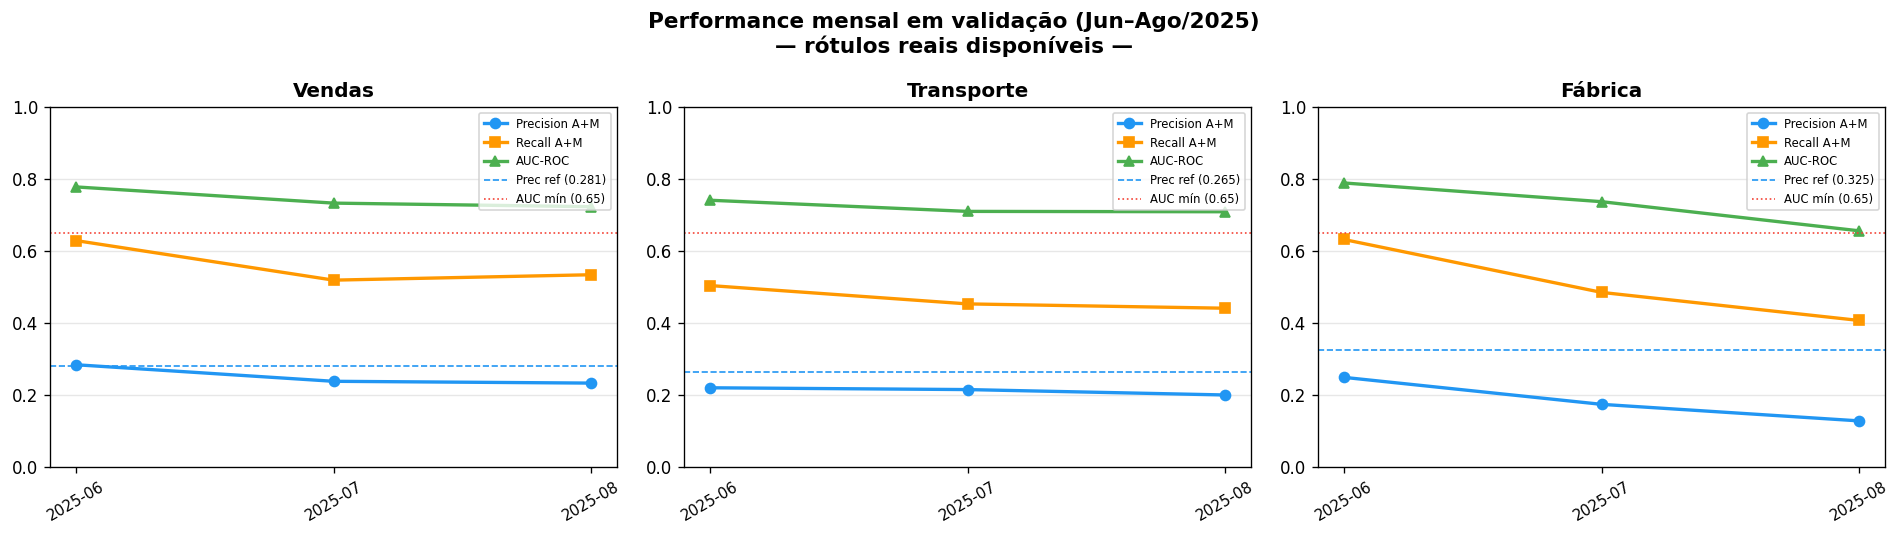

✓ monitor_performance_val.png salvo


In [9]:
# ── Figura 3: Performance mensal em validação ─────────────────
row_meses = []
for grupo in GRUPOS:
    dg = df_val_score[df_val_score[COL_GRUPO] == grupo]
    for mes in sorted(dg[COL_DATA].unique()):
        dm   = dg[dg[COL_DATA] == mes]
        y    = dm[COL_TARGET].fillna(0).astype(int)
        pred = dm["pred_am"]
        prec = precision_score(y, pred, zero_division=0)
        rec  = recall_score(y, pred, zero_division=0)
        try:
            auc = roc_auc_score(y, dm["proba_turnover"])
        except Exception:
            auc = np.nan
        row_meses.append({"grupo": grupo,
                          "mes": mes.strftime("%Y-%m"),
                          "prec_AM": round(prec, 3),
                          "rec_AM" : round(rec,  3),
                          "auc_roc": round(auc,  3)})

df_perf_mes = pd.DataFrame(row_meses)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
fig.suptitle("Performance mensal em validação (Jun–Ago/2025)\n"
             "— rótulos reais disponíveis —",
             fontsize=13, fontweight="bold")

for ax, grupo in zip(axes, GRUPOS):
    sub  = df_perf_mes[df_perf_mes["grupo"] == grupo]
    meses = sub["mes"].tolist()
    x = range(len(meses))

    ax.plot(x, sub["prec_AM"], "o-", color="#2196F3", label="Precision A+M", lw=2)
    ax.plot(x, sub["rec_AM"],  "s-", color="#FF9800", label="Recall A+M",    lw=2)
    ax.plot(x, sub["auc_roc"], "^-", color="#4CAF50", label="AUC-ROC",       lw=2)
    ax.axhline(PRECISION_AM_REF[grupo], color="#2196F3", ls="--", lw=1,
               label=f"Prec ref ({PRECISION_AM_REF[grupo]:.3f})")
    ax.axhline(AUC_MIN, color="#F44336", ls=":", lw=1,
               label=f"AUC mín ({AUC_MIN:.2f})")

    ax.set_xticks(list(x))
    ax.set_xticklabels(meses, rotation=30, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(grupo, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitor_performance_val.png", bbox_inches="tight")
plt.show()
print(f"✓ monitor_performance_val.png salvo")

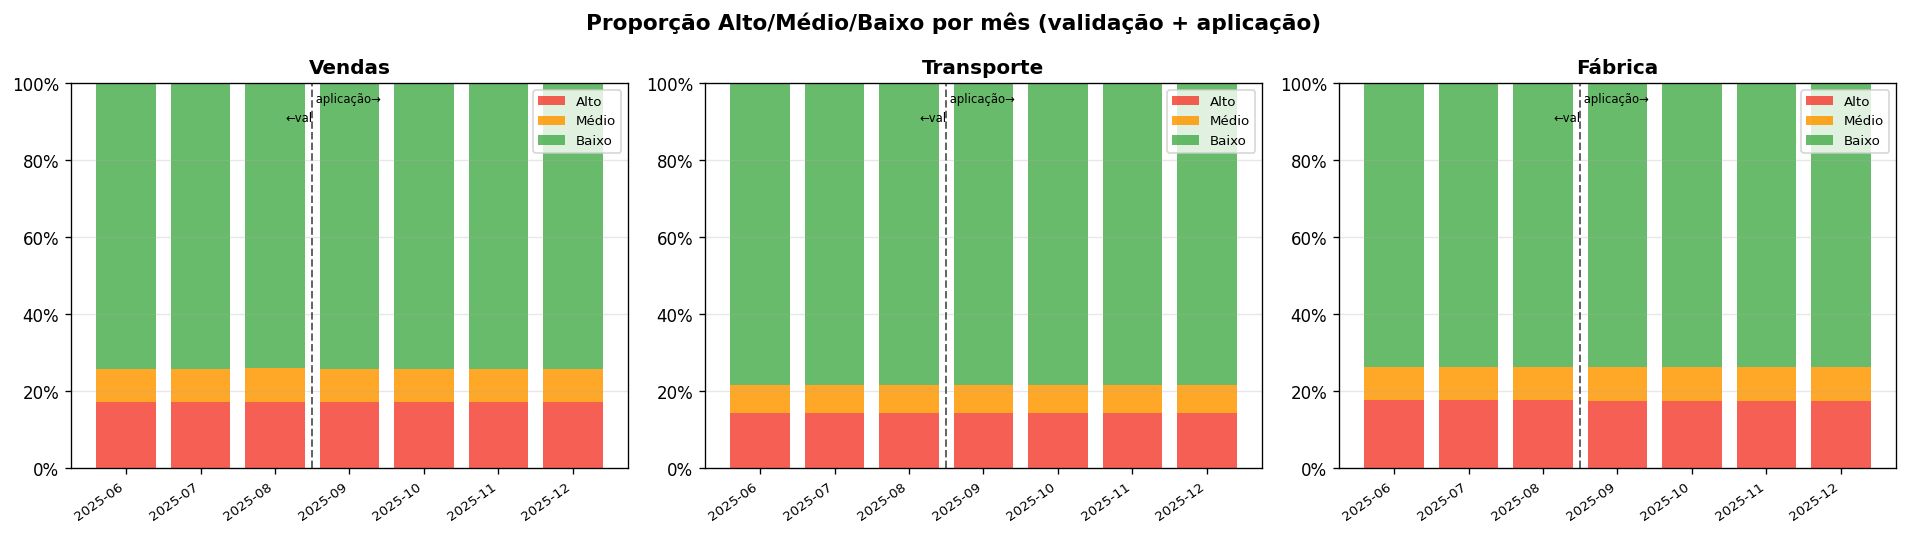

✓ monitor_classificacao_tempo.png salvo


In [10]:
# ── Figura 4: Classificação mês a mês (val + aplicação) ───────
# Proporção Alto / Médio / Baixo ao longo do tempo

# Combinar val + apl com rótulos de classificação
df_timeline = pd.concat([
    df_val_score[[COL_GRUPO, COL_DATA, "grupo_risco"]].assign(periodo="val"),
    score_apl[[COL_GRUPO, COL_DATA, "grupo_risco"]].assign(periodo="apl"),
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Proporção Alto/Médio/Baixo por mês (validação + aplicação)",
             fontsize=13, fontweight="bold")

CORES_RISCO = {"Alto": "#F44336", "Médio": "#FF9800", "Baixo": "#4CAF50"}

for ax, grupo in zip(axes, GRUPOS):
    sub = df_timeline[df_timeline[COL_GRUPO] == grupo].copy()
    sub["mes_str"] = sub[COL_DATA].dt.strftime("%Y-%m")

    pct = (sub.groupby(["mes_str", "grupo_risco"])
             .size()
             .unstack(fill_value=0)
             .apply(lambda r: r / r.sum(), axis=1)
             * 100)

    meses_sorted = sorted(pct.index.tolist())
    pct = pct.reindex(meses_sorted)

    bottom = np.zeros(len(meses_sorted))
    x = np.arange(len(meses_sorted))

    for cat in ["Alto", "Médio", "Baixo"]:
        if cat in pct.columns:
            vals = pct[cat].values
            ax.bar(x, vals, bottom=bottom, color=CORES_RISCO[cat],
                   label=cat, alpha=0.85)
            bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(meses_sorted, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(grupo, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    # Separador val / apl
    val_meses = sorted(df_val_score.loc[df_val_score[COL_GRUPO]==grupo,
                                         COL_DATA].dt.strftime("%Y-%m").unique())
    n_val = len(val_meses)
    if n_val < len(meses_sorted):
        ax.axvline(n_val - 0.5, color="black", ls="--", lw=1.2, alpha=0.6)
        ax.text(n_val - 0.5, 95, " aplicação→", fontsize=7, color="black")
        ax.text(n_val - 0.5, 90, "←val", fontsize=7, color="black",
                ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "monitor_classificacao_tempo.png", bbox_inches="tight")
plt.show()
print(f"✓ monitor_classificacao_tempo.png salvo")

## 7 · Critérios de retreino e sumário executivo

In [11]:
# ────────────────────────────────────────────────────────────────
# Consolida todos os sinais e emite recomendação de retreino
# ────────────────────────────────────────────────────────────────

print("=" * 72)
print("SUMÁRIO EXECUTIVO DE MONITORAMENTO")
print("=" * 72)
print(f"Data de execução: {datetime.now():%Y-%m-%d %H:%M}")
print()

retreinar = False

for grupo in GRUPOS:
    alertas = []

    # --- Performance
    perf_row = df_perf[df_perf["grupo"] == grupo].iloc[0]
    if perf_row["auc_roc"] < AUC_MIN:
        alertas.append(f"AUC-ROC={perf_row['auc_roc']:.3f} < {AUC_MIN} (mínimo)")
        retreinar = True
    delta_prec = abs(perf_row["prec_AM"] - perf_row["prec_AM_ref"])
    if delta_prec > 0.05:
        alertas.append(f"Precision A+M real={perf_row['prec_AM']:.3f} vs "
                       f"ref={perf_row['prec_AM_ref']:.3f} (delta={delta_prec:.3f})")
        retreinar = True

    # --- Drift PSI
    psi_criticos = df_psi[
        (df_psi["grupo"] == grupo) & (df_psi["psi_apl"] >= PSI_ALERT)
    ]
    if len(psi_criticos) > 0:
        feats = psi_criticos["feature"].tolist()
        alertas.append(f"Drift crítico (PSI≥{PSI_ALERT}) em: {feats}")
        retreinar = True

    psi_moderados = df_psi[
        (df_psi["grupo"] == grupo) &
        (df_psi["psi_apl"] >= PSI_WARN) &
        (df_psi["psi_apl"] < PSI_ALERT)
    ]

    status_icon = "⚠️" if alertas else "✅"
    print(f"  {grupo}  {status_icon}")
    print(f"    AUC-ROC={perf_row['auc_roc']:.3f}  "
          f"Prec A+M={perf_row['prec_AM']:.3f} (ref={perf_row['prec_AM_ref']:.3f})  "
          f"Recall A+M={perf_row['rec_AM']:.3f}")
    print(f"    PSI features alertas moderados : "
          f"{len(psi_moderados)}  |  críticos: {len(psi_criticos)}")
    if alertas:
        print(f"    ⚠  ALERTAS:")
        for a in alertas:
            print(f"       · {a}")
    print()

print("═" * 72)
if retreinar:
    print("  🔴 RECOMENDAÇÃO: UM OU MAIS GRUPOS PRECISAM DE ATENÇÃO")
    print("     Revisar alertas acima. Considerar retreino se persiste")
    print("     por mais de 1 ciclo mensal.")
else:
    print("  🟢 MODELO ESTÁVEL: nenhum sinal de alerta crítico detectado.")
    print("     Recomendação: re-executar este notebook mensalmente.")
print("═" * 72)

print()
print("Critérios de retreino adotados:")
print(f"  · AUC-ROC < {AUC_MIN}")
print(f"  · Precision A+M com desvio > 5pp da referência do ROI")
print(f"  · PSI ≥ {PSI_ALERT} em qualquer feature top-{TOP_N_SHAP}")
print()
print("✅ 10_monitor.ipynb concluído.")

SUMÁRIO EXECUTIVO DE MONITORAMENTO
Data de execução: 2026-05-05 15:43

  Vendas  ⚠️
    AUC-ROC=0.744  Prec A+M=0.252 (ref=0.281)  Recall A+M=0.561
    PSI features alertas moderados : 0  |  críticos: 2
    ⚠  ALERTAS:
       · Drift crítico (PSI≥0.2) em: ['vl_horas_extras_extraordinarias_horas', 'vl_horas_trabalhadas_std_3m']

  Transporte  ⚠️
    AUC-ROC=0.718  Prec A+M=0.212 (ref=0.265)  Recall A+M=0.465
    PSI features alertas moderados : 0  |  críticos: 2
    ⚠  ALERTAS:
       · Precision A+M real=0.212 vs ref=0.265 (delta=0.053)
       · Drift crítico (PSI≥0.2) em: ['vl_falta_dias_max_6m_bin', 'vl_tv_vol_uorg_4m']

  Fábrica  ⚠️
    AUC-ROC=0.734  Prec A+M=0.184 (ref=0.325)  Recall A+M=0.517
    PSI features alertas moderados : 1  |  críticos: 1
    ⚠  ALERTAS:
       · Precision A+M real=0.184 vs ref=0.325 (delta=0.141)
       · Drift crítico (PSI≥0.2) em: ['vl_saldo_banco_horas_med_3m_std_3m']

════════════════════════════════════════════════════════════════════════
  🔴 RECOM